## 1. Setup and Baseline Parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler

# Ensure directory for plots exists
os.makedirs('../reports/figures/', exist_ok=True)

def load_hmd_mx(filepath):
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['Total'])

# Load and Filter
df = load_hmd_mx('../data/Mx_1x1.txt')
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total').replace(0, 1e-8)
log_mx = np.log(mx_matrix)

# SVD with strict LC constraints: sum(bx)=1, sum(kt)=0
alpha_x = log_mx.mean(axis=1)
Z = log_mx.sub(alpha_x, axis=0)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)

# Normalization (Anticipating "Identifiability" objection)
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()

# Align trend: kt should decrease
if kt[0] < kt[-1]: kt, bx = -kt, -bx

years = mx_matrix.columns
print("Baseline Lee-Carter parameters extracted successfully.")

Baseline Lee-Carter parameters extracted successfully.


## 2. Forecasting $\kappa_t$ (Random Walk with Drift)

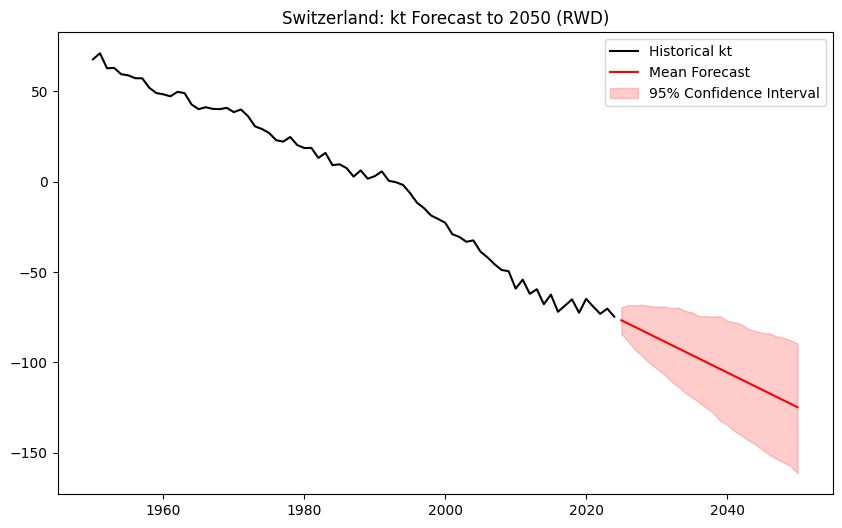

In [2]:
n_years = 2050 - years[-1]
last_kt = kt[-1]
drift = np.mean(np.diff(kt))
sigma = np.std(np.diff(kt))

forecast_years = np.arange(years[-1] + 1, 2051)
kt_forecast = last_kt + drift * (forecast_years - years[-1])

# Monte Carlo Simulations
n_sims = 1000
simulations = np.zeros((n_sims, n_years))
for i in range(n_sims):
    innovations = np.random.normal(0, sigma, n_years)
    simulations[i, :] = last_kt + np.cumsum(drift + innovations)

plt.figure(figsize=(10, 6))
plt.plot(years, kt, color='black', label='Historical kt')
plt.plot(forecast_years, kt_forecast, color='red', label='Mean Forecast')
plt.fill_between(forecast_years, 
                 np.percentile(simulations, 2.5, axis=0), 
                 np.percentile(simulations, 97.5, axis=0), 
                 color='red', alpha=0.2, label='95% Confidence Interval')
plt.title('Switzerland: kt Forecast to 2050 (RWD)')
plt.legend()
plt.savefig('../reports/figures/04_kt_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Life Expectancy Projection

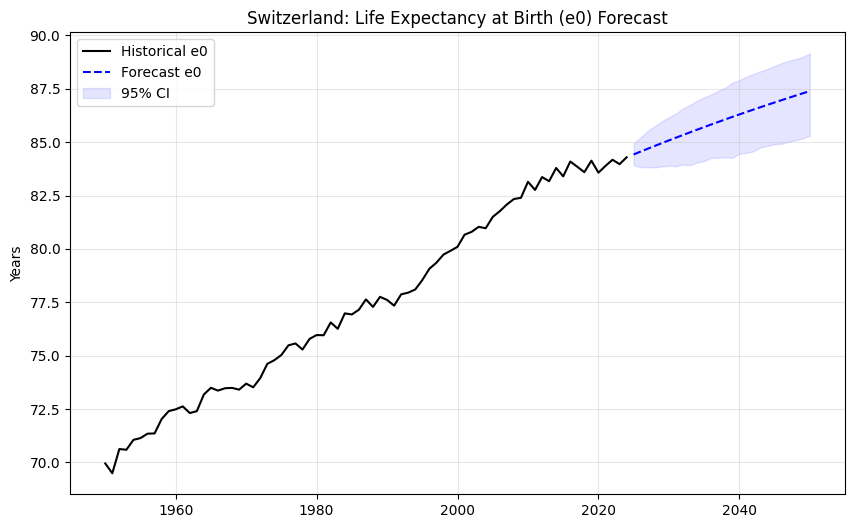

Projected Life Expectancy in 2050: 87.39 years


In [3]:
def calculate_life_expectancy(mx):
    px = np.exp(-mx)
    lx = np.concatenate(([1], np.cumprod(px[:-1])))
    return np.sum(lx)

e0_hist = [calculate_life_expectancy(np.exp(alpha_x + bx * k)) for k in kt]
e0_forecast = [calculate_life_expectancy(np.exp(alpha_x + bx * k)) for k in kt_forecast]

# Uncertainty bounds for e0
kt_lower = np.percentile(simulations, 2.5, axis=0)
kt_upper = np.percentile(simulations, 97.5, axis=0)
e0_lower = [calculate_life_expectancy(np.exp(alpha_x + bx * k)) for k in kt_upper]
e0_upper = [calculate_life_expectancy(np.exp(alpha_x + bx * k)) for k in kt_lower]

plt.figure(figsize=(10, 6))
plt.plot(years, e0_hist, color='black', label='Historical e0')
plt.plot(forecast_years, e0_forecast, color='blue', linestyle='--', label='Forecast e0')
plt.fill_between(forecast_years, e0_lower, e0_upper, color='blue', alpha=0.1, label='95% CI')
plt.title('Switzerland: Life Expectancy at Birth (e0) Forecast')
plt.ylabel('Years')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('../reports/figures/05_e0_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Projected Life Expectancy in 2050: {e0_forecast[-1]:.2f} years")

## 4. Data Preparation for Neural Network

In [4]:
# Preparing features: (Age, Year) -> log_mx
df_nn = df_clean[['Age', 'Year', 'Total']].copy()
df_nn['log_mx'] = np.log(df_nn['Total'])

X = df_nn[['Age', 'Year']].values
y = df_nn['log_mx'].values

scaler_y = StandardScaler()
X_scaled = X.copy()
X_scaled[:, 1] = scaler_y.fit_transform(X[:, 1].reshape(-1, 1)).flatten()

print(f"Dataset ready: {len(df_nn)} samples.")

Dataset ready: 7200 samples.


## 5. Deep Lee-Carter Training

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2026-03-12 14:32:19.221928: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-12 14:32:19.221966: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-12 14:32:19.221971: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-12 14:32:19.222024: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-12 14:32:19.222057: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:

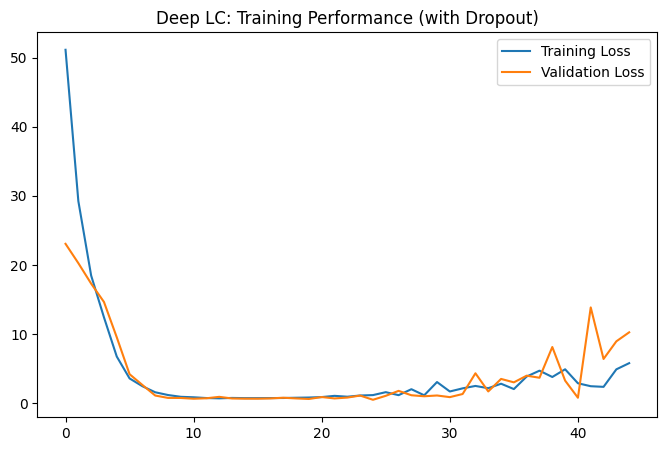

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Multi-Layer Perceptron with Dropout for Regularization
model = Sequential([
    Input(shape=(2,)),
    Dense(64, activation='relu'),
    Dropout(0.1), # Prevents memorization of noise
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_scaled, y, 
    epochs=250, 
    batch_size=64, 
    validation_split=0.2, 
    callbacks=[early_stop], 
    verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Deep LC: Training Performance (with Dropout)')
plt.legend()
plt.savefig('../reports/figures/06_nn_training.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Final Comparison (Smoothing)

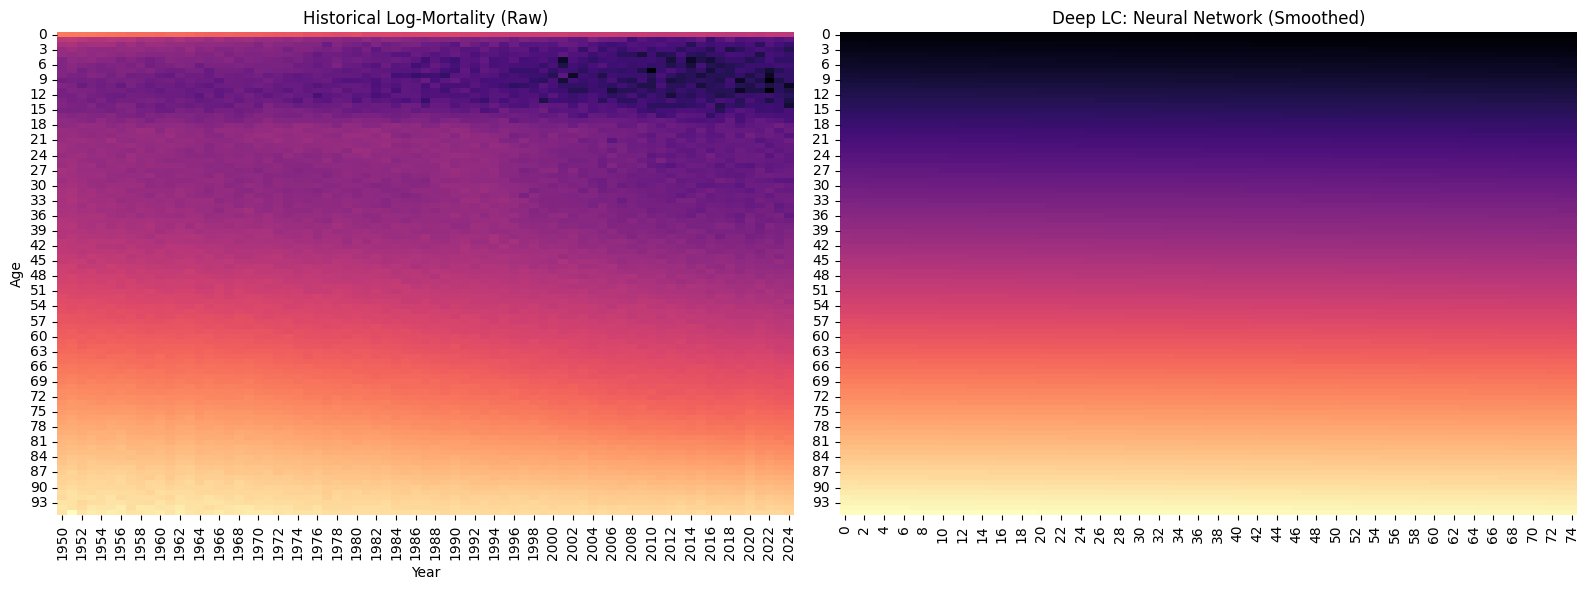

In [6]:
# Generate Grid for prediction
all_ages = np.arange(0, 96)
all_years = np.arange(1950, 2025)
year_grid, age_grid = np.meshgrid(all_years, all_ages)

X_grid = np.stack([age_grid.ravel(), year_grid.ravel()], axis=1)
X_grid_scaled = X_grid.copy().astype(float)
X_grid_scaled[:, 1] = scaler_y.transform(X_grid[:, 1].reshape(-1, 1)).flatten()

log_mx_pred = model.predict(X_grid_scaled, verbose=0).reshape(len(all_ages), len(all_years))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(log_mx, ax=ax[0], cmap='magma', cbar=False)
ax[0].set_title('Historical Log-Mortality (Raw)')

sns.heatmap(log_mx_pred, ax=ax[1], cmap='magma', cbar=False)
ax[1].set_title('Deep LC: Neural Network (Smoothed)')

plt.tight_layout()
plt.savefig('../reports/figures/07_nn_vs_raw.png', dpi=300, bbox_inches='tight')
plt.show()